# **Import Data**

In [ ]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/datascience/Mini Projects/Diamond Dynamics: Price Prediction and Market Segmentation/cleaned_data.csv")
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.50,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.80,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,58.75,63.5,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.40,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.30,58.0,335.0,4.34,4.35,2.75


In [ ]:
data.describe()

,carat,depth,table,price,x,y,z
count,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.792471,61.748112,57.439612,3732.953436,5.731306,5.733398,3.538454
std,0.456694,1.269642,2.160989,3436.710718,1.119038,1.111074,0.691833
min,0.200000,58.750000,51.500000,326.000000,1.965000,1.990000,1.230000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,2.000000,64.750000,63.500000,11890.375000,9.285000,9.270000,5.710000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53794 non-null  float64
 1   cut      53794 non-null  object 
 2   color    53794 non-null  object 
 3   clarity  53794 non-null  object 
 4   depth    53794 non-null  float64
 5   table    53794 non-null  float64
 6   price    53794 non-null  float64
 7   x        53794 non-null  float64
 8   y        53794 non-null  float64
 9   z        53794 non-null  float64
dtypes: float64(7), object(3)
memory usage: 4.1+ MB


# **Exploratory Data Analysis (EDA)**

/tmp/ipykernel_2213/2310903118.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='cut', y='price', palette='viridis', ax=axes[1, 0])
/tmp/ipykernel_2213/2310903118.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='color', y='price', palette='magma', ax=axes[1, 1])
/tmp/ipykernel_2213/2310903118.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='clarity', y='price', palette='rocket', ax=axes[2, 0]) # FIX: Moved from [2,1] to keep layout tight
/tmp/ipykernel_2213/2310903118.py:39: FutureWarning:

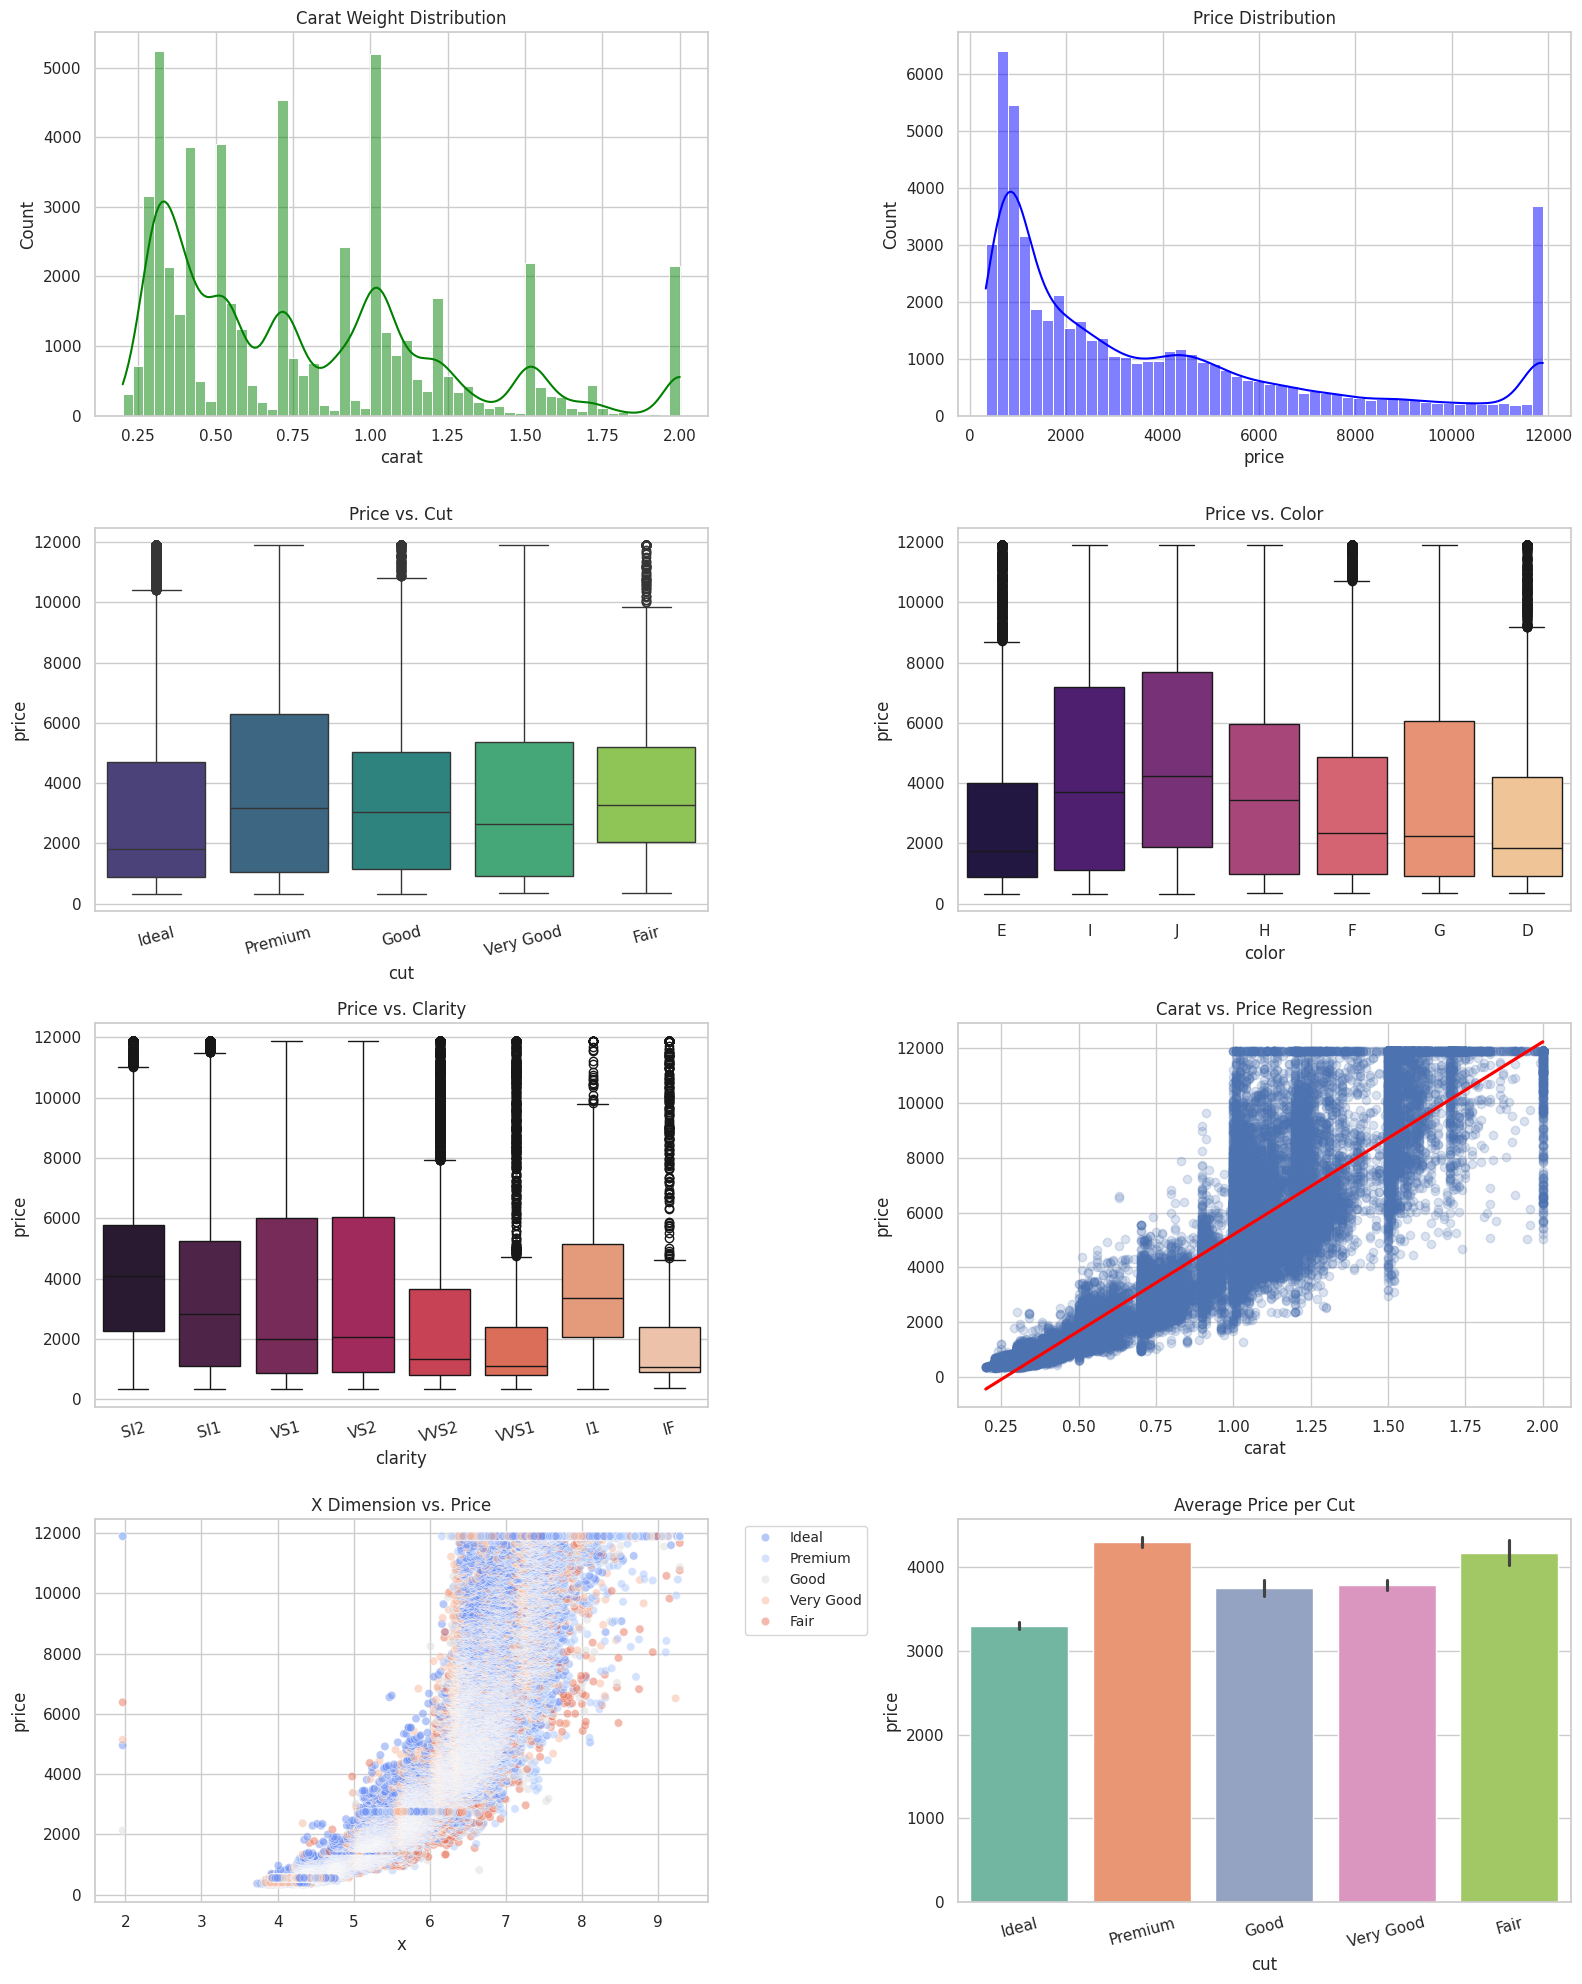

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# --- Distributions ---
sns.histplot(data['carat'], kde=True, color='green', ax=axes[0, 0])
axes[0, 0].set_title('Carat Weight Distribution')

sns.histplot(data['price'], kde=True, color='blue', ax=axes[0, 1])
axes[0, 1].set_title('Price Distribution')

# --- ROW 1: Categorical Boxplots (Cut & Color) ---
sns.boxplot(data=data, x='cut', y='price', palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Price vs. Cut')
axes[1, 0].tick_params(axis='x', rotation=15)

sns.boxplot(data=data, x='color', y='price', palette='magma', ax=axes[1, 1])
axes[1, 1].set_title('Price vs. Color')

# --- ROW 2: Clarity Boxplot & Regression ---
sns.boxplot(data=data, x='clarity', y='price', palette='rocket', ax=axes[2, 0]) # FIX: Moved from [2,1] to keep layout tight
axes[2, 0].set_title('Price vs. Clarity')
axes[2, 0].tick_params(axis='x', rotation=15)

sns.regplot(data=data, x='carat', y='price', scatter_kws={'alpha':0.2}, line_kws={'color':'red'}, ax=axes[2, 1]) # FIX: Changed from [2,2] to [2,1]
axes[2, 1].set_title('Carat vs. Price Regression')

# --- ROW 3: Dimension Scatter & Average Bar Chart ---
sns.scatterplot(data=data, x='x', y='price', hue='cut', palette='coolwarm', alpha=0.5, ax=axes[3, 0]) # FIX: Changed from [3,1] to [3,0]
axes[3, 0].set_title('X Dimension vs. Price')
axes[3, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

sns.barplot(data=data, x='cut', y='price', estimator='mean', palette='Set2', ax=axes[3, 1]) # FIX: Changed from [3,2] to [3,1]
axes[3, 1].set_title('Average Price per Cut')
axes[3, 1].tick_params(axis='x', rotation=15)

# Prevent title/label clipping between charts
plt.tight_layout()
plt.show()


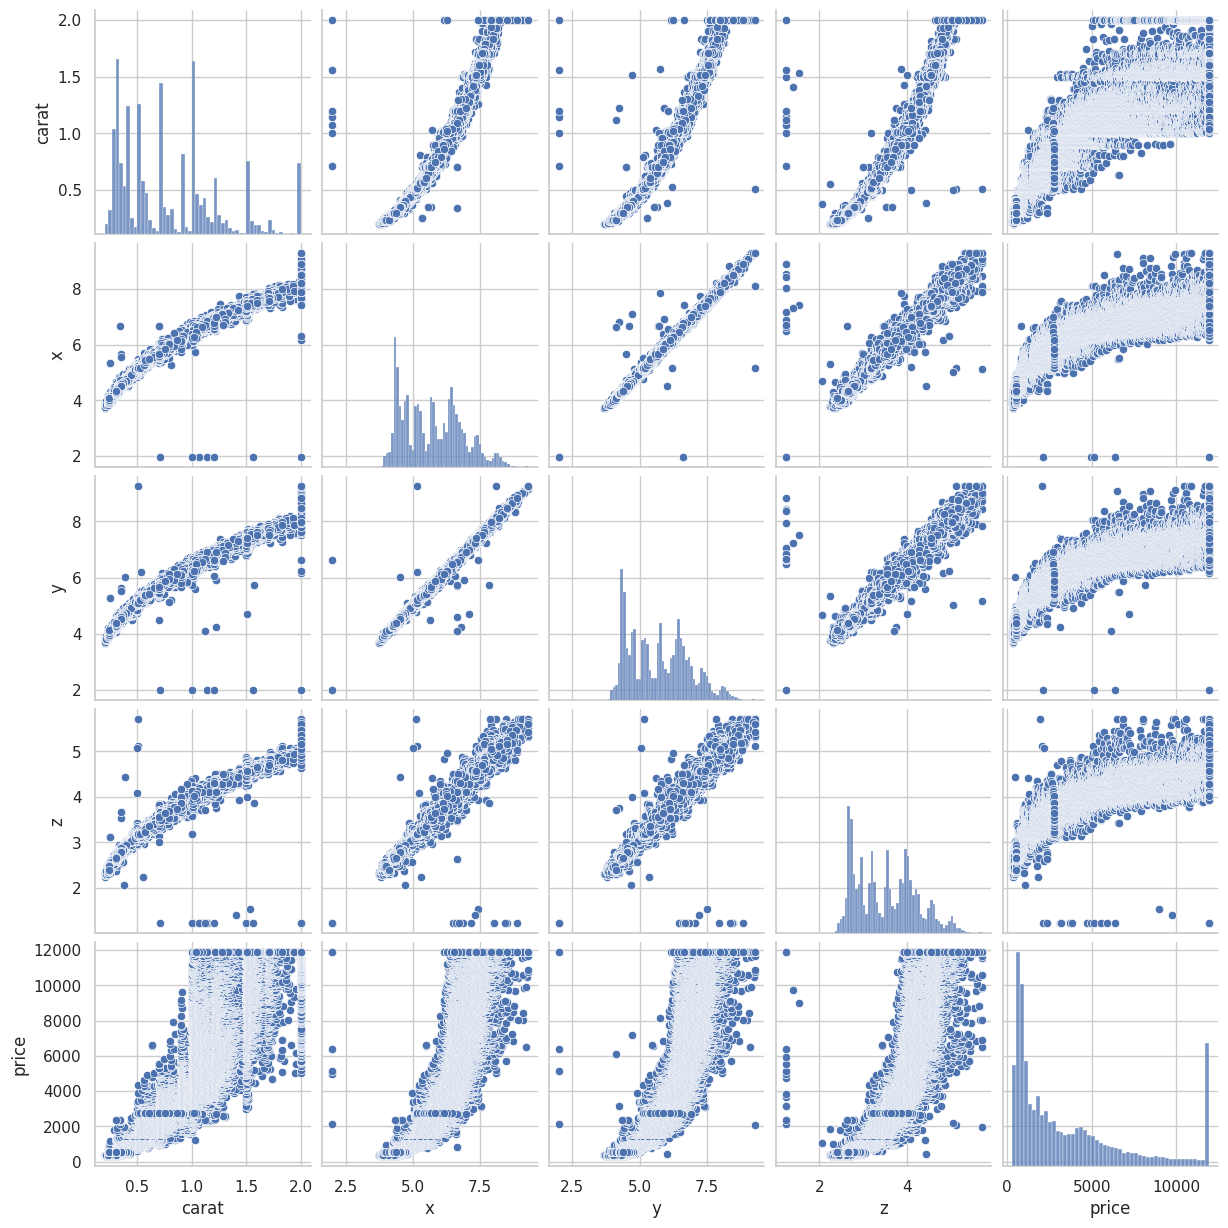

In [ ]:
# Pairwise Relationships
sns.pairplot(data[['carat', 'x', 'y', 'z','price']])
plt.show()

# **Feature Selection**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Define categories
categories = [
    ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    ["J", "I", "H", "G", "F", "E", "D"],
    ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
]

# Initialize encoder
encoder = OrdinalEncoder(categories=categories)

# Transform the columns
transformed_data = encoder.fit_transform(data[['cut', 'color', 'clarity']])

# Assign back to data and convert to int
data[['cut', 'color', 'clarity']] = transformed_data.astype(int)

# Create a dictionary to store the mappings
mappings = {}

for i, col in enumerate(['cut', 'color', 'clarity']):
    # Extract categories and create a {Value: Number} dictionary
    mappings[col] = {category: index for index, category in enumerate(encoder.categories_[i])}

# Print the mappings clearly
print("--- Diamond Feature Mappings ---")
for feature, mapping in mappings.items():
    print(f"\n{feature.upper()}:")
    for category, value in mapping.items():
        print(f"  {category} -> {value}")

data[['cut', 'color', 'clarity']].head()

--- Diamond Feature Mappings ---

CUT:
  Fair -> 0
  Good -> 1
  Very Good -> 2
  Premium -> 3
  Ideal -> 4

COLOR:
  J -> 0
  I -> 1
  H -> 2
  G -> 3
  F -> 4
  E -> 5
  D -> 6

CLARITY:
  I1 -> 0
  SI2 -> 1
  SI1 -> 2
  VS2 -> 3
  VS1 -> 4
  VVS2 -> 5
  VVS1 -> 6
  IF -> 7


,cut,color,clarity
0,4,5,1
1,3,5,2
2,1,5,4
3,3,1,3
4,1,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer
import pandas as pd

# Ensure you have your original DataFrame ready
numeric_cols = ['depth', 'table', 'x', 'y', 'z']
pos_skewed_cols = ['carat','price']

# Scale and assign BACK to the specific columns
scaler = StandardScaler()
skewness = FunctionTransformer(np.log1p, validate=True)

# THE FIX: Don't overwrite the whole 'data' variable with the array.
# Instead, assign the result directly to the columns of the DataFrame.
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
data[pos_skewed_cols] = skewness.fit_transform(data[pos_skewed_cols])

# Now 'data' is still a DataFrame and .head() will work perfectly
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.207014,4,5,1,-0.195421,-1.128944,5.789960,-1.591834,-1.578125,-1.602213
1,0.190620,3,5,2,-1.534394,1.647588,5.789960,-1.645452,-1.704130,-1.775667
2,0.207014,1,5,4,-2.361406,2.804477,5.793014,-1.502471,-1.497122,-1.775667
3,0.254642,3,1,3,0.513447,0.259322,5.814131,-1.368426,-1.353115,-1.313123
4,0.270027,1,0,1,1.222315,0.259322,5.817111,-1.243317,-1.245111,-1.139669


# **Using Random Forest**

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Define Features (X) and Target (y)
X = data.drop('price', axis=1)
y = data['price']

# Fit the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Get and display feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importances:\n", importances)

Feature Importances:
 y          0.723552
carat      0.213148
clarity    0.030729
color      0.014189
x          0.013230
z          0.001621
depth      0.001316
cut        0.001203
table      0.001012
dtype: float64


# **Using Correlation Matrix**

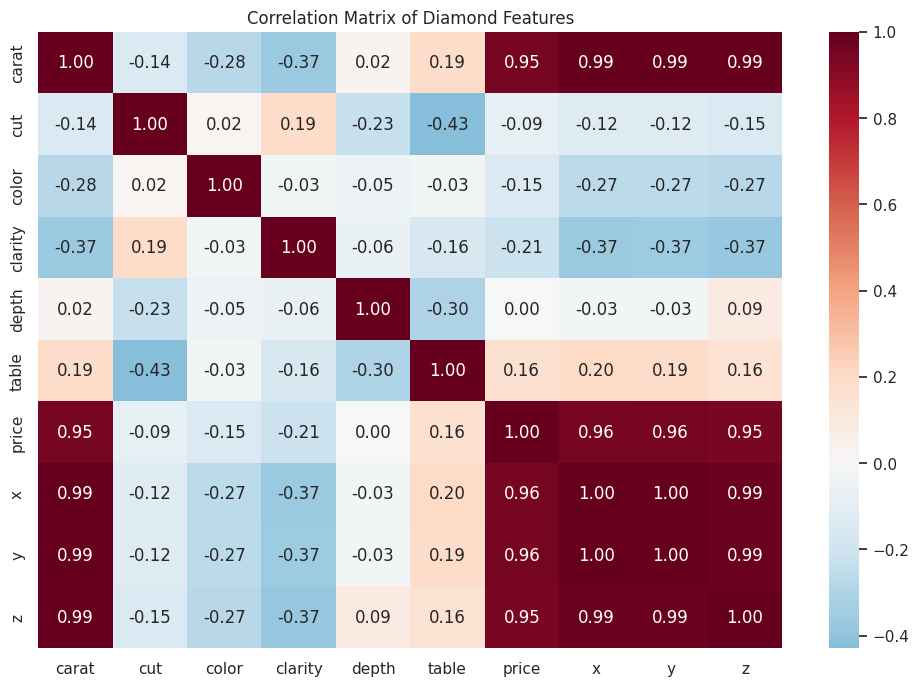

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation for numerical columns only
corr_matrix = data.select_dtypes(include=['number']).corr()

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlation Matrix of Diamond Features')
plt.show()
